
make sure to import quickdraw first, collab doesnt default have it
```
pip install quickdraw
```



imports and configs

In [13]:
from quickdraw import QuickDrawDataGroup
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

CATEGORIES = ["apple", "banana", "cat", "dog"]
SAMPLES = 500

Load images

In [32]:
images = []
labels = []

for category in CATEGORIES:
    group = QuickDrawDataGroup(category, max_drawings=SAMPLES)
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((100, 100)))
        images.append(img)
        labels.append(category)




loading apple drawings
load complete
loading banana drawings
load complete
loading cat drawings
load complete
loading dog drawings
load complete


display of categories

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

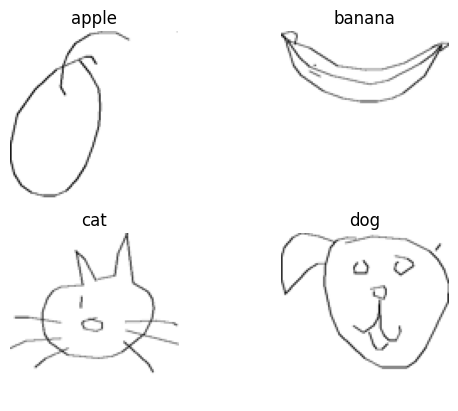

In [33]:
plt.subplot(2, 2, 1)
plt.imshow(images[0], cmap='gray')
plt.title(labels[0])
plt.axis('off')


plt.subplot(2, 2, 2)
plt.imshow(images[500], cmap='gray')
plt.title(labels[500])
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(images[1000], cmap='gray')
plt.title(labels[1000])
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(images[1500], cmap='gray')
plt.title(labels[1500])
plt.axis('off')



Split into test train sets

In [16]:
label_map = {
    "apple": 0,
    "banana": 1,
    "cat": 2,
    "dog": 3,
}


X=np.array(images) / 255.0 # standardize to (0,1)
y=np.array(labels)
y = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (1600, 32, 32), Test: (400, 32, 32)


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (N, 4096)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

num_classes = len(np.unique(y))

# torch tensors
X_train_t = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)


class RawPixel(nn.Module):
    def __init__(self, input_size=64*64, num_classes=len(CATEGORIES)):
        super().__init__()

        # 1024 -> 256 -> 128 -> # 4 Categories
        self.fc1 = nn.Linear(input_size, 256) # 32 x 32 = 1024
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


More configs and seetings bruh

In [18]:
dims = X_train_flat.shape[1]
classes = len(CATEGORIES)

model = RawPixel(input_size=dims, num_classes=classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)



RawPixel(
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

In [19]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # one hot encoding
        yb_onehot = F.one_hot(yb, num_classes=num_classes).float()

        # reset gradient
        optimizer.zero_grad()

        # grab preds
        logits = model(xb)
        loss = criterion(logits, yb_onehot)


        #update gradient and step
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)


    correct, total = 0, 0
    model.eval()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_eval, y_eval in test_loader:
            x_eval, y_eval = x_eval.to(device), y_eval.to(device)
            preds = model(x_eval).argmax(dim=1)
            correct += (preds == y_eval).sum().item()
            total += y_eval.size(0)

    test_acc = correct / total
    print(f"Epoch: {epoch+1} | loss: {train_loss:.4f} | acc: {test_acc:.4f}")




Epoch: 1 | loss: 0.1984 | acc: 0.2500
Epoch: 2 | loss: 0.1938 | acc: 0.2500
Epoch: 3 | loss: 0.1903 | acc: 0.2500
Epoch: 4 | loss: 0.1876 | acc: 0.2500
Epoch: 5 | loss: 0.1889 | acc: 0.2500
Epoch: 6 | loss: 0.1872 | acc: 0.4475
Epoch: 7 | loss: 0.1845 | acc: 0.2700
Epoch: 8 | loss: 0.1839 | acc: 0.3625
Epoch: 9 | loss: 0.1816 | acc: 0.2500
Epoch: 10 | loss: 0.1811 | acc: 0.2500
Epoch: 11 | loss: 0.1750 | acc: 0.5100
Epoch: 12 | loss: 0.1716 | acc: 0.3750
Epoch: 13 | loss: 0.1674 | acc: 0.5200
Epoch: 14 | loss: 0.1576 | acc: 0.4975
Epoch: 15 | loss: 0.1585 | acc: 0.4375


Confusion Matrix

400 400
              precision    recall  f1-score   support

       apple       0.52      0.98      0.68       100
      banana       0.00      0.00      0.00       100
         cat       0.27      0.30      0.29       100
         dog       0.47      0.47      0.47       100

    accuracy                           0.44       400
   macro avg       0.31      0.44      0.36       400
weighted avg       0.31      0.44      0.36       400



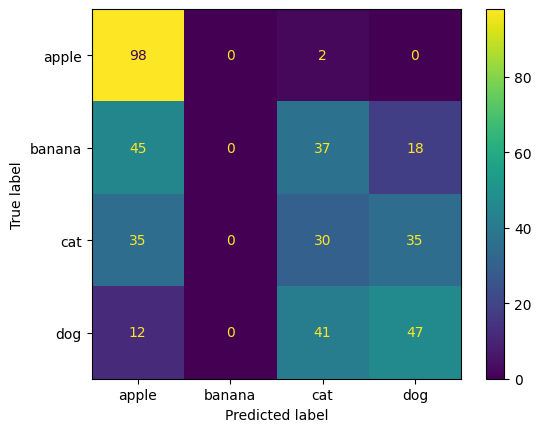

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_eval, y_eval in test_loader:
        x_eval, y_eval = x_eval.to(device), y_eval.to(device)
        batch_preds = model(x_eval).argmax(dim=1)
        all_preds.append(batch_preds.cpu())
        all_labels.append(y_eval.cpu())

preds = torch.cat(all_preds).numpy()
y_test = torch.cat(all_labels).numpy()
print(len(preds), len(y_test))

print(classification_report(y_test, preds, target_names=label_map, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=label_map)